# WCS 01 — Header & Solve Diagnostics

**What this notebook tests:**
- Did astrometry.net return plain TAN or TAN-SIP (distortion-aware) WCS?
- Are matched sources spread across the full field, or clustered?
- Do the CRVAL/CRPIX/CD numbers look self-consistent?

All results are cached to `out/wcs_diagnostics/` so re-runs are instant.

In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from extractor.platesolve import platesolve, has_sip, wcs_summary
from astropy.io import fits as afits
from astropy.wcs import WCS

DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'out' / 'wcs_diagnostics'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE    = OUT_DIR / 'platesolve_result.pkl'
SAVE_DIR = OUT_DIR / 'products'   # raw astrometry.net product files saved here

fits_files = sorted(DATA_DIR.glob('*.fit')) + sorted(DATA_DIR.glob('*.fits'))
if not fits_files:
    raise FileNotFoundError(f'No FITS files in {DATA_DIR}')
image_path = fits_files[0]
print(f'Image     : {image_path.name}')

with afits.open(image_path) as hdul:
    image  = hdul[0].data.astype(float)
    orig_header = hdul[0].header.copy()

h, w = image.shape
print(f'Shape     : {w} × {h} px')
print(f'Cache     : {CACHE}  (exists: {CACHE.exists()})')
print()
if CACHE.exists():
    print('TIP: Delete the cache file to force a fresh solve and re-fetch product tables.')


Image     : fuji6_asi178_100_15s.fit
Shape     : 3096 × 2080 px
Cache     : C:\Users\bassd\Research\Spectra Angle\spectrangle\out\wcs_diagnostics\platesolve_result.pkl  (exists: False)



In [2]:
result = platesolve(
    image_path,
    write=False,
    verbose=True,
    cache=CACHE,
    fetch_products=True,
    save_products_dir=SAVE_DIR,
)


Logged in to nova.astrometry.net
Detected 255 sources (mask_spectra=True).
Source list uploaded (submission 14945354)
Waiting for job assignment. job 15781285
Solving. solved!
WCS header fetched.
Fetching astrometry.net products:
  corr: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/corr_file/15781285
  corr: 14400 bytes, first 16: b'SIMPLE  =       '
  corr: HDU0=PrimaryHDU, HDU1=BinTableHDU
  corr: 48 rows | cols: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']
  axy: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/axy_file/15781285
  axy: 11520 bytes, first 16: b'SIMPLE  =       '
  axy: HDU0=PrimaryHDU, HDU1=BinTableHDU
  axy: 255 rows | cols: ['X', 'Y']
  rdls: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/rdls_file/15781285
  rdls: 69120 bytes, first 16: b'SIMPLE  =       '
  rdls

In [3]:
assert result is not None, 'Solve failed'

# --- Job metadata ---
print('=== Job metadata ===')
print(f'  Submission ID : {getattr(result, "submission_id", "n/a (old cache)")}')
print(f'  Job ID        : {getattr(result, "job_id",        "n/a (old cache)")}')
print(f'  Status        : {getattr(result, "status",        "unknown")}')
print()

# --- Fetch status for each product ---
fetch_status = getattr(result, 'fetch_status', {})
print('=== Product fetch status ===')
if not fetch_status:
    print('  (no fetch_status recorded — cache predates product fetching)')
    print('  Delete the cache file and re-run to fetch corr/axy/rdls/image_rd tables.')
else:
    for name, msg in fetch_status.items():
        tag = 'OK  ' if msg == 'ok' else 'FAIL'
        print(f'  [{tag}] {name:12s}: {msg}')
print()

# --- Source counts ---
print('=== Source counts ===')
print(f'  Local detected (submitted) : {len(result.detected_x)}')
print(f'  Matched (from corr)        : {len(result.matched_x)}')
for attr, label in [('corr_table',        'corr rows          '),
                     ('axy_table',         'axy rows (astr det)'),
                     ('rdls_table',        'rdls rows (ref cat)'),
                     ('image_radec_table', 'image_rd rows      ')]:
    tbl = getattr(result, attr, None)
    if tbl is not None:
        print(f'  {label}: {len(tbl)}  cols: {tbl.colnames}')
    else:
        print(f'  {label}: not available')
print()

# --- WCS summary ---
print('=== WCS summary ===')
print(wcs_summary(result.header))
print()
print(f'  has_sip : {has_sip(result.header)}')
print(f'  CRVAL1  : {result.header.get("CRVAL1", float("nan")):.6f}°  (RA  of CRPIX)')
print(f'  CRVAL2  : {result.header.get("CRVAL2", float("nan")):.6f}°  (Dec of CRPIX)')

cd11 = result.header.get('CD1_1', 0)
cd12 = result.header.get('CD1_2', 0)
cd21 = result.header.get('CD2_1', 0)
cd22 = result.header.get('CD2_2', 0)
scale_x = np.hypot(cd11, cd21) * 3600
scale_y = np.hypot(cd12, cd22) * 3600
print(f'  Scale   : {scale_x:.2f}" × {scale_y:.2f}" / px')
print(f'  FOV     : {w * scale_x / 3600:.2f}° × {h * scale_y / 3600:.2f}°')


=== Job metadata ===
  Submission ID : 14945354
  Job ID        : 15781285
  Status        : success

=== Product fetch status ===
  [OK  ] corr        : ok
  [OK  ] axy         : ok
  [OK  ] rdls        : ok
  [OK  ] image_rd    : ok

=== Source counts ===
  Local detected (submitted) : 255
  Matched (from corr)        : 48
  corr rows          : 48  cols: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']
  axy rows (astr det): 255  cols: ['X', 'Y']
  rdls rows (ref cat): 179  cols: ['MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG', 'RA', 'DEC']
  image_rd rows      : 255  cols: ['ra', 'dec', 'x', 'y']

=== WCS summary ===
  CTYPE1  : RA---TAN-SIP
  CTYPE2  : DEC--TAN-SIP
  CRVAL1  : 120.61262
  CRVAL2  : 29.788056
  CRPIX1  : 1286.8585
  CRPIX2  : 1140.5638
  CD1_1   : -0.0218561
  CD1_2   : 0.00514579
  CD2_1   : -0.00525836
  CD2_2   : -0.0219369
  SIP     : yes (order 2)

 

In [4]:
# Pixel → world → pixel roundtrip check for detected sources
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    wcs = WCS(result.header)

xy_in  = np.column_stack([result.detected_x, result.detected_y])
sky    = wcs.pixel_to_world_values(*xy_in.T)   # (ra_arr, dec_arr)
xy_out = np.column_stack(wcs.world_to_pixel_values(*sky))
errors = np.hypot(*(xy_out - xy_in).T)
print('=== Pixel → sky → pixel roundtrip ===')
print(f'  Max error  : {errors.max():.2e} px')
print(f'  Mean error : {errors.mean():.2e} px')
assert errors.max() < 0.01, 'Roundtrip error unexpectedly large — check WCS origin convention'

=== Pixel → sky → pixel roundtrip ===
  Max error  : 2.76e-07 px
  Mean error : 5.90e-09 px


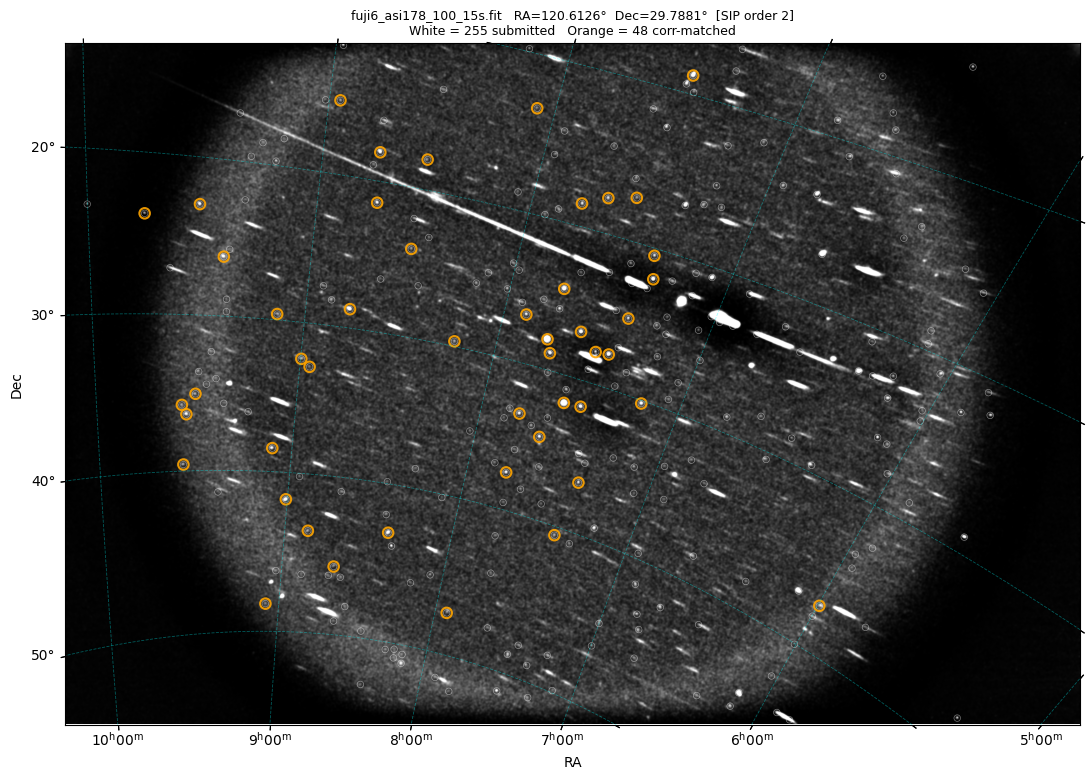

Saved wcs01_full_field.png


In [5]:
bg   = gaussian_filter(image.astype(np.float32), sigma=50.0)
proc = np.clip(image.astype(np.float32) - bg, 0.0, None)
proc = gaussian_filter(proc, sigma=2.5)
lo, hi = np.percentile(proc[np.isfinite(proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(proc, lo, hi))

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    wcs = WCS(result.header)

fig, ax = plt.subplots(figsize=(11, 9), subplot_kw={'projection': wcs})
ax.imshow(disp, origin='lower', cmap='gray',
          vmin=np.arcsinh(lo), vmax=np.arcsinh(hi))
ax.coords.grid(True, color='cyan', alpha=0.35, linestyle='--', linewidth=0.6)
ax.coords['ra'].set_axislabel('RA')
ax.coords['dec'].set_axislabel('Dec')

# Submitted sources (thin white)
for x, y in zip(result.detected_x, result.detected_y):
    ax.add_patch(Circle((x, y), radius=10, edgecolor='white', facecolor='none',
                         linewidth=0.5, alpha=0.45))

# Corr matched sources (orange, field_x/y from corr table)
corr_table = getattr(result, 'corr_table', None)
if corr_table is not None:
    fx_col = 'field_x' if 'field_x' in corr_table.colnames else 'FIELD_X'
    fy_col = 'field_y' if 'field_y' in corr_table.colnames else 'FIELD_Y'
    if fx_col in corr_table.colnames:
        for x, y in zip(corr_table[fx_col], corr_table[fy_col]):
            ax.add_patch(Circle((float(x), float(y)), radius=16,
                                 edgecolor='orange', facecolor='none',
                                 linewidth=1.5, alpha=0.9))

ax.set_xlim(-0.5, w - 0.5)
ax.set_ylim(-0.5, h - 0.5)
sip_label = (f"SIP order {max(result.header.get('A_ORDER', 0), result.header.get('B_ORDER', 0))}"
             if has_sip(result.header) else 'no SIP')
n_corr = len(corr_table) if corr_table is not None else 0
ax.set_title(
    f"{image_path.name}   RA={result.header.get('CRVAL1', 0):.4f}°  "
    f"Dec={result.header.get('CRVAL2', 0):.4f}°  [{sip_label}]\n"
    f"White = {len(result.detected_x)} submitted   Orange = {n_corr} corr-matched",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs01_full_field.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs01_full_field.png')


In [6]:
# Show first rows of each available product table
for attr, label in [
    ('corr_table',        'corr.fits    — correspondence (field↔catalog)'),
    ('axy_table',         'axy.fits     — sources used by astrometry.net'),
    ('rdls_table',        'rdls.fits    — reference catalog stars'),
    ('image_radec_table', 'image-radec  — submitted sources projected to sky'),
]:
    tbl = getattr(result, attr, None)
    if tbl is not None:
        print(f'\n=== {label} ===')
        print(f'Columns: {tbl.colnames}')
        print(tbl[:5])
    else:
        status = getattr(result, 'fetch_status', {}).get(
            attr.replace('_table', '').replace('image_radec', 'image_rd'), 'not attempted')
        print(f'\n=== {label} ===')
        print(f'  Not available.  fetch_status: {status}')



=== corr.fits    — correspondence (field↔catalog) ===
Columns: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']
     field_x            field_y       ... MAG_HP  MAG 
------------------ ------------------ ... ------ -----
 1520.872794832787  980.5949937212513 ...  1.934 1.934
 868.6421742163291 1266.4891102949723 ...    0.0 4.126
 672.9387986457484  686.3982697210052 ...    0.0 4.026
410.93971428736074 1586.9875743792782 ...    0.0 4.475
1471.0606695672434 1174.6071973571072 ...    0.0 1.325

=== axy.fits     — sources used by astrometry.net ===
Columns: ['X', 'Y']
        X                  Y         
------------------ ------------------
1876.4846362086423 1290.2362336609035
 1520.872794832787  980.5949937212513
2308.6925786689912 1433.6422533751884
2237.3959909944583  406.8383288910846
 868.6421742163291 1266.4891102949723

=== rdls.fits    — reference catalog 

In [7]:
# ── Debug cell: test corr fetch directly (authenticated) ──────────────────────
# Run this if corr_table shows FAIL above.  Uses the same API-key login that
# platesolve() uses so the Django session cookie is present for the corr URL.
import io
import json
import requests
from astropy.io import fits as _dbg_fits
from astropy.table import Table as _dbg_Table

_api_key_path = ROOT / 'astrometry_api.txt'
_api_key = _api_key_path.read_text().strip()

# Login via requests.Session so the session cookie is preserved
_dbg_sess = requests.Session()
_lr = _dbg_sess.post(
    'https://nova.astrometry.net/api/login',
    data={'request-json': json.dumps({'apikey': _api_key})},
    timeout=30,
)
_lr.raise_for_status()
print(f"Login status : {_lr.json().get('status')}")
print(f"Session cookies: {dict(_dbg_sess.cookies)}")

_job_id = result.job_id
_url = f"https://nova.astrometry.net/corr_file/{_job_id}"
print(f"\njob_id             : {_job_id}")
print(f"URL                : {_url}")

_r = _dbg_sess.get(_url, timeout=60)
print(f"\nHTTP status        : {_r.status_code}")
print(f"Content-Type       : {_r.headers.get('content-type', '?')}")
print(f"Final URL          : {_r.url}")
print(f"Size               : {len(_r.content)} bytes")
print(f"First 80 bytes     : {_r.content[:80]!r}")
print(f"Starts with SIMPLE : {_r.content.startswith(b'SIMPLE')}")

if _r.content.startswith(b'SIMPLE'):
    print()
    with _dbg_fits.open(io.BytesIO(_r.content)) as _hdul:
        _hdul.info()
        _table_hdu = next(
            (h for h in _hdul
             if isinstance(h, (_dbg_fits.BinTableHDU, _dbg_fits.TableHDU))),
            None,
        )
        if _table_hdu is not None:
            _corr_debug = _dbg_Table(_table_hdu.data)
            print(f"\nCorr columns ({len(_corr_debug)} rows): {_corr_debug.colnames}")
            display(_corr_debug[:5])
        else:
            print("FITS opened but no BinTableHDU — HDUs:",
                  [type(h).__name__ for h in _hdul])
else:
    print("\nServer did NOT return a FITS file.")
    print("Preview (first 500 chars decoded):")
    print(_r.content[:500].decode('utf-8', errors='replace'))
    if _r.status_code == 200 and b'ask_human' in _r.content:
        print("\nRedirected to ask_human — session cookie was not accepted.")
        print("The platesolve() fix (using requests.Session throughout) should resolve this.")


Login status : success
Session cookies: {'csrftoken': 'SiHterlC9MQkaZ6GPHpAxa97QRBoziy5', 'CCNovaAstrometrySession': 'q1uc3lbixnaodp5bac3p6c2914bgi1n7'}

job_id             : 15781285
URL                : https://nova.astrometry.net/corr_file/15781285

HTTP status        : 200
Content-Type       : application/fits
Final URL          : https://nova.astrometry.net/corr_file/15781285
Size               : 14400 bytes
First 80 bytes     : b'SIMPLE  =                    T / Standard FITS file                             '
Starts with SIMPLE : True

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     51   48R x 15C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1J, 1J, 1D, 1E, 1E, 1E, 1E]   

Corr columns (48 rows): ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP'

field_x,field_y,field_ra,field_dec,index_x,index_y,index_ra,index_dec,index_id,field_id,match_weight,MAG_BT,MAG_VT,MAG_HP,MAG
float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,float64,float32,float32,float32,float32
1520.872794832787,980.5949937212513,113.65123487912224,31.877190742229537,1520.7789545087314,980.101413302649,113.65001898992675,31.888636439629515,177,1,0.999400107564071,0.0,0.0,1.934,1.934
868.6421742163291,1266.4891102949723,131.69380287221955,28.756832120543923,869.4548481799179,1266.256568360255,131.67430806951214,28.760005002607514,178,4,0.999531198867162,5.252,4.126,0.0,4.126
672.9387986457484,686.3982697210052,135.156050672452,41.77067788442159,672.7278507291783,685.8684427187289,135.16135861683634,41.78339304650341,39,5,0.9989453802846292,4.493,4.026,0.0,4.026
410.93971428736074,1586.9875743792782,142.93919314373923,22.95867605175326,411.43723406062963,1586.5029850123155,142.93016527064583,22.968062779049962,27,7,0.9984371422761612,6.323,4.475,0.0,4.475
1471.0606695672434,1174.6071973571072,116.26257187795508,27.999940118673308,1468.1540833932102,1174.194244633394,116.33068263380711,28.026310298455115,176,8,0.995842414340037,2.455,1.325,0.0,1.325


In [8]:
# ── Validation cell: verify saved corr.fits on disk ───────────────────────────
# Checks that the file saved by platesolve() to SAVE_DIR is a valid FITS table.
import io
from astropy.io import fits as _val_fits
from astropy.table import Table as _val_Table

_corr_path = SAVE_DIR / 'corr.fits'
print(f"Looking for saved corr.fits at: {_corr_path}")

if not _corr_path.exists():
    print("File does not exist — either fetch failed or save_products_dir was not set.")
    print("Re-run the solve cell with fetch_products=True and save_products_dir=SAVE_DIR.")
else:
    _raw = _corr_path.read_bytes()
    print(f"File size          : {len(_raw)} bytes")
    print(f"First 16 bytes     : {_raw[:16]!r}")
    print(f"Starts with SIMPLE : {_raw.startswith(b'SIMPLE')}")
    if _raw.startswith(b'SIMPLE'):
        with _val_fits.open(_corr_path) as _hdul:
            _hdul.info()
            _table_hdu = next(
                (h for h in _hdul
                 if isinstance(h, (_val_fits.BinTableHDU, _val_fits.TableHDU))),
                None,
            )
            if _table_hdu is not None:
                _saved_corr = _val_Table(_table_hdu.data)
                print(f"\nRows               : {len(_saved_corr)}")
                print(f"Columns            : {_saved_corr.colnames}")
                print("\nFirst 5 rows:")
                display(_saved_corr[:5])
            else:
                print("FITS opened but no BinTableHDU — HDUs:",
                      [type(h).__name__ for h in _hdul])
    else:
        print("Saved file is NOT valid FITS — likely an HTML error page was written to disk.")
        print("Delete", _corr_path, "and the cache, then re-solve.")


Looking for saved corr.fits at: C:\Users\bassd\Research\Spectra Angle\spectrangle\out\wcs_diagnostics\products\corr.fits
File size          : 14400 bytes
First 16 bytes     : b'SIMPLE  =       '
Starts with SIMPLE : True
Filename: C:\Users\bassd\Research\Spectra Angle\spectrangle\out\wcs_diagnostics\products\corr.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     51   48R x 15C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1J, 1J, 1D, 1E, 1E, 1E, 1E]   

Rows               : 48
Columns            : ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']

First 5 rows:


field_x,field_y,field_ra,field_dec,index_x,index_y,index_ra,index_dec,index_id,field_id,match_weight,MAG_BT,MAG_VT,MAG_HP,MAG
float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,float64,float32,float32,float32,float32
1520.872794832787,980.5949937212513,113.65123487912224,31.877190742229537,1520.7789545087314,980.101413302649,113.65001898992675,31.888636439629515,177,1,0.999400107564071,0.0,0.0,1.934,1.934
868.6421742163291,1266.4891102949723,131.69380287221955,28.756832120543923,869.4548481799179,1266.256568360255,131.67430806951214,28.760005002607514,178,4,0.999531198867162,5.252,4.126,0.0,4.126
672.9387986457484,686.3982697210052,135.156050672452,41.77067788442159,672.7278507291783,685.8684427187289,135.16135861683634,41.78339304650341,39,5,0.9989453802846292,4.493,4.026,0.0,4.026
410.93971428736074,1586.9875743792782,142.93919314373923,22.95867605175326,411.43723406062963,1586.5029850123155,142.93016527064583,22.968062779049962,27,7,0.9984371422761612,6.323,4.475,0.0,4.475
1471.0606695672434,1174.6071973571072,116.26257187795508,27.999940118673308,1468.1540833932102,1174.194244633394,116.33068263380711,28.026310298455115,176,8,0.995842414340037,2.455,1.325,0.0,1.325


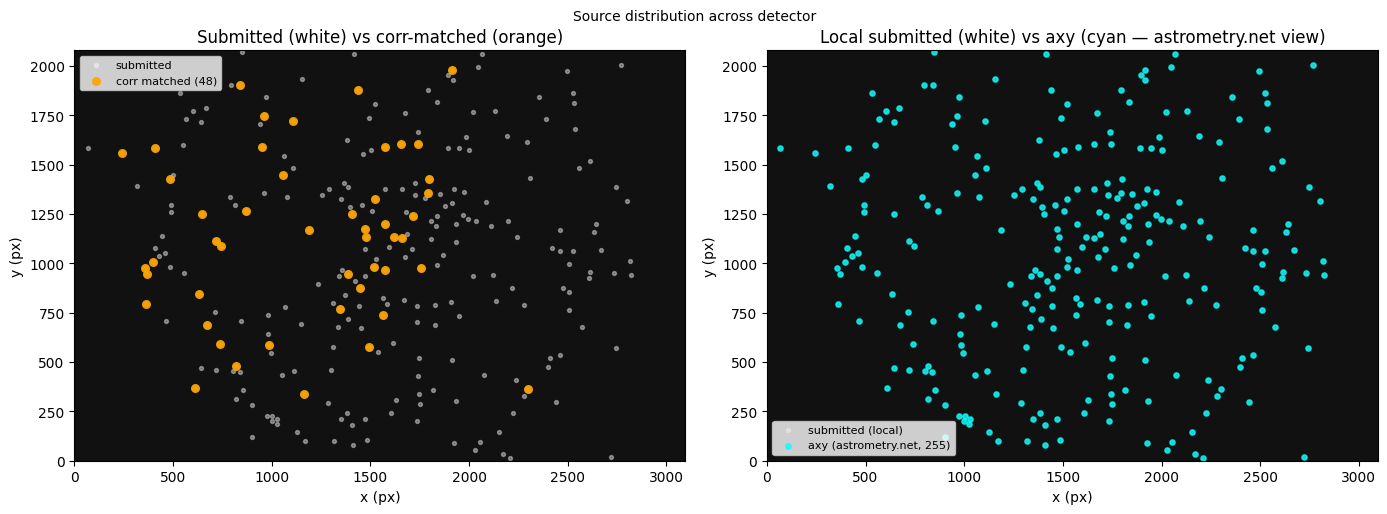

Saved wcs01_source_distribution.png


In [9]:
# Spatial distribution: submitted vs corr-matched, coloured by source
corr_table = getattr(result, 'corr_table', None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax in axes:
    ax.set_facecolor('#111')
    ax.set_xlim(0, w); ax.set_ylim(0, h)
    ax.set_aspect('equal')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

# Left: submitted vs corr-matched
ax = axes[0]
ax.scatter(result.detected_x, result.detected_y, s=8, c='white', alpha=0.4, label='submitted')
if corr_table is not None:
    fx_col = 'field_x' if 'field_x' in corr_table.colnames else 'FIELD_X'
    fy_col = 'field_y' if 'field_y' in corr_table.colnames else 'FIELD_Y'
    if fx_col in corr_table.colnames:
        ax.scatter(corr_table[fx_col], corr_table[fy_col],
                   s=30, c='orange', alpha=0.9, label=f'corr matched ({len(corr_table)})')
ax.set_title('Submitted (white) vs corr-matched (orange)')
ax.legend(fontsize=8)

# Right: axy sources (what astrometry.net actually used)
ax = axes[1]
axy_table = getattr(result, 'axy_table', None)
ax.scatter(result.detected_x, result.detected_y, s=8, c='white', alpha=0.3, label='submitted (local)')
if axy_table is not None:
    x_col = 'X' if 'X' in axy_table.colnames else axy_table.colnames[0]
    y_col = 'Y' if 'Y' in axy_table.colnames else axy_table.colnames[1]
    ax.scatter(axy_table[x_col], axy_table[y_col],
               s=15, c='cyan', alpha=0.7, label=f'axy (astrometry.net, {len(axy_table)})')
    ax.set_title('Local submitted (white) vs axy (cyan — astrometry.net view)')
else:
    ax.set_title('axy.fits not available')
ax.legend(fontsize=8)

plt.suptitle('Source distribution across detector', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs01_source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs01_source_distribution.png')


## Interpretation

**Product fetch status:** All four table products (corr, axy, rdls, image_rd) should show `[OK]`. If any show `FAIL`, the most common cause is that the job ID was from an old solve and the files have expired on nova.astrometry.net. Delete the cache and re-solve.

**Good WCS outcome:** CTYPE ends in `-SIP`, corr-matched sources are spread across the full field (not clustered), plate scale is consistent with expectations, and the roundtrip error is < 0.01 px.

**What each product tells you:**
- **corr.fits** — the correspondence table used in `wcs_02` to compute WCS residuals. The most important product.
- **axy.fits** — the sources astrometry.net actually used for solving. For an xylist submission this is typically identical to what we submitted. Differences would indicate astrometry.net filtered some sources.
- **rdls.fits** — reference catalog stars in the solved field. Useful for checking catalog coverage.
- **image-radec.fits** — submitted sources projected to sky through the solved WCS.

**No SIP terms:** If CTYPE shows plain TAN, astrometry.net returned a linear-only WCS. For a ~70° field at 81"/px, expect field-dependent angle errors toward the edges — the local Jacobian (wcs_04) will quantify this.

**If corr shows 0 rows but solve succeeded:** The fetch of corr.fits failed silently in old versions. Delete the cache and re-run with the updated `platesolve.py` which reports fetch failures explicitly.
